# Análisis Exploratorio de Datos (EDA)
## Airbnb Ciudad de México
### Inteligencia de Negocios — Taller Evaluativo 3

**Objetivo:** Analizar el mercado de alojamientos de Airbnb en Ciudad de México, enfocándose en precios, disponibilidad, distribución geográfica y perfil de los anfitriones.

---

In [1]:
import sys
import os
sys.path.append(os.path.join('..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from extraccion import Extraccion

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 1. Extracción desde MongoDB

In [2]:
ext = Extraccion()
df_listings, df_reviews, df_calendar = ext.extraer_todo()
ext.cerrar_conexion()

print(f'Listings:  {len(df_listings):,} registros | {df_listings.shape[1]} columnas')
print(f'Reviews:   {len(df_reviews):,} registros | {df_reviews.shape[1]} columnas')
print(f'Calendar:  {len(df_calendar):,} registros | {df_calendar.shape[1]} columnas')

2026-04-17 17:14:19 - INFO - Logger iniciado para el modulo: extraccion
2026-04-17 17:14:19 - INFO - Archivo de log: c:\Users\Usuario\Documents\GitHub\bi_itm\etl_airbnb\entrega3\logs\log_extraccion_20260417_1714.txt
2026-04-17 17:14:19 - INFO - Intentando conectar a MongoDB: mongodb://localhost:27017/
2026-04-17 17:14:19 - INFO - Conexion exitosa a la base de datos: 'airbnb_itm'
2026-04-17 17:14:19 - INFO - Iniciando extraccion completa de todas las colecciones.
2026-04-17 17:14:19 - INFO - Extrayendo coleccion: 'Listings_mexico'
2026-04-17 17:14:22 - INFO - Coleccion 'Listings_mexico' extraida correctamente. Registros: 27,051 | Columnas: 76
2026-04-17 17:14:22 - INFO - Extrayendo coleccion: 'Reviews_mexico'
2026-04-17 17:14:33 - INFO - Coleccion 'Reviews_mexico' extraida correctamente. Registros: 1,454,740 | Columnas: 6
2026-04-17 17:14:33 - INFO - Extrayendo coleccion: 'Calendar_mexico'
2026-04-17 17:15:26 - INFO - Coleccion 'Calendar_mexico' extraida correctamente. Registros: 9,873,

Listings:  27,051 registros | 76 columnas
Reviews:   1,454,740 registros | 6 columnas
Calendar:  9,873,624 registros | 5 columnas


---
## 2. Entendimiento general de Listings

A diferencia del dataset de Buenos Aires, el dataset de Ciudad de México **sí contiene el campo `price`** directamente en la tabla de listings. Esto permite analizar precios por tipo de alojamiento, barrio y perfil del anfitrión.

In [3]:
df_listings.head(3)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,...,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,host_neighbourhood,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
0,35797,https://www.airbnb.com/rooms/35797,20250927041820,2025-09-27,city scrape,Villa Dante,"Dentro de Villa un estudio de arte con futon, ...","Santa Fe Shopping Mall, Interlomas Park and th...",https://a0.muscache.com/pictures/f395ab78-1185...,153786,https://www.airbnb.com/users/show/153786,Dici,2010-06-28,"Mexico City, Mexico","Master in visual arts, film photography & Mark...",N/A,N/A,N/A,False,https://a0.muscache.com/im/pictures/user/00de1...,https://a0.muscache.com/im/pictures/user/00de1...,1.00,1.00,"['email', 'phone', 'work_email']",True,...,363,2025-09-27,0,0,0,94,0,0,0.00,False,1,1,0,0,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,44616,https://www.airbnb.com/rooms/44616,20250927041820,2025-09-28,city scrape,Condesa Haus,A new concept of hosting in mexico through a b...,NaN,https://a0.muscache.com/pictures/251410/ec75fe...,196253,https://www.airbnb.com/users/show/196253,Fernando,2010-08-09,"Mexico City, Mexico",Condesa Haus Rentals offers independent stud...,within an hour,100%,92%,False,https://a0.muscache.com/im/users/196253/profil...,https://a0.muscache.com/im/users/196253/profil...,13.00,13.00,"['email', 'phone', 'work_email']",True,...,360,2025-09-28,65,1,0,90,0,6,108000.00,False,9,4,2,0,Condesa,2011-11-09,2025-01-01,4.59,4.56,4.70,4.87,4.78,4.98,4.47,0.38
2,56074,https://www.airbnb.com/rooms/56074,20250927041820,2025-09-28,city scrape,Great space in historical San Rafael,This great apartment is located in one of the ...,Very traditional neighborhood with all service...,https://a0.muscache.com/pictures/3005118/60dac...,265650,https://www.airbnb.com/users/show/265650,Maris,2010-10-19,"Mexico City, Mexico",I am a University Professor now retired after ...,within a day,100%,100%,True,https://a0.muscache.com/im/users/265650/profil...,https://a0.muscache.com/im/users/265650/profil...,1.00,5.00,"['email', 'phone']",True,...,333,2025-09-28,84,1,0,63,0,30,17730.00,False,1,1,0,0,San Rafael,2011-04-02,2025-02-27,4.87,4.95,4.88,4.98,4.94,4.76,4.79,0.48


In [4]:
print(f'Shape: {df_listings.shape}')
df_listings.info()

Shape: (27051, 76)
<class 'pandas.DataFrame'>
RangeIndex: 27051 entries, 0 to 27050
Data columns (total 76 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            27051 non-null  int64         
 1   listing_url                                   27051 non-null  str           
 2   scrape_id                                     27051 non-null  int64         
 3   last_scraped                                  27051 non-null  datetime64[us]
 4   source                                        27051 non-null  str           
 5   name                                          27051 non-null  object        
 6   description                                   26309 non-null  str           
 7   neighborhood_overview                         13736 non-null  str           
 8   picture_url                                   27051 non-nu

In [5]:
# Estadísticas descriptivas de variables numéricas clave
cols_num = ['price', 'minimum_nights', 'maximum_nights',
            'availability_365', 'number_of_reviews',
            'review_scores_rating', 'accommodates',
            'bedrooms', 'beds', 'bathrooms']
cols_ok = [c for c in cols_num if c in df_listings.columns]
df_listings[cols_ok].describe()

,minimum_nights,maximum_nights,availability_365,number_of_reviews,review_scores_rating,accommodates,bedrooms,beds,bathrooms
count,27051.00,27051.00,27051.00,27051.00,23650.00,27051.00,26071.00,23545.00,23555.00
mean,4.58,480.08,232.69,53.78,4.75,3.34,1.55,1.96,1.45
std,24.78,396.36,122.27,85.14,0.38,2.34,1.26,1.76,1.03
min,1.00,1.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00
25%,1.00,180.00,140.00,4.00,4.70,2.00,1.00,1.00,1.00
50%,2.00,365.00,269.00,21.00,4.84,2.00,1.00,1.00,1.00
75%,2.00,730.00,341.00,69.00,4.95,4.00,2.00,2.00,2.00
max,1125.00,1127.00,365.00,1434.00,5.00,16.00,50.00,50.00,49.00


---
## 3. Calidad de datos — Nulos y duplicados

In [6]:
def resumen_nulos(df, nombre):
    nulos = df.isnull().sum()
    pct   = (nulos / len(df) * 100).round(2)
    res   = pd.DataFrame({'Nulos': nulos, '% Nulos': pct})
    res   = res[res['Nulos'] > 0].sort_values('% Nulos', ascending=False)
    print(f'\n--- Nulos: {nombre} ---')
    print(res.to_string())
    return res

nulos_l = resumen_nulos(df_listings, 'Listings')
nulos_r = resumen_nulos(df_reviews,  'Reviews')
nulos_c = resumen_nulos(df_calendar, 'Calendar')


--- Nulos: Listings ---
                             Nulos  % Nulos
neighborhood_overview        13315    49.22
neighbourhood                13315    49.22
host_neighbourhood           12264    45.34
host_about                   10829    40.03
host_location                 5827    21.54
beds                          3506    12.96
bathrooms                     3496    12.92
estimated_revenue_l365d       3484    12.88
price                         3484    12.88
review_scores_checkin         3402    12.58
review_scores_communication   3402    12.58
review_scores_accuracy        3402    12.58
review_scores_cleanliness     3402    12.58
review_scores_value           3402    12.58
review_scores_location        3402    12.58
reviews_per_month             3401    12.57
review_scores_rating          3401    12.57
last_review                   3401    12.57
first_review                  3401    12.57
host_is_superhost             1665     6.16
has_availability              1016     3.76
bedroom

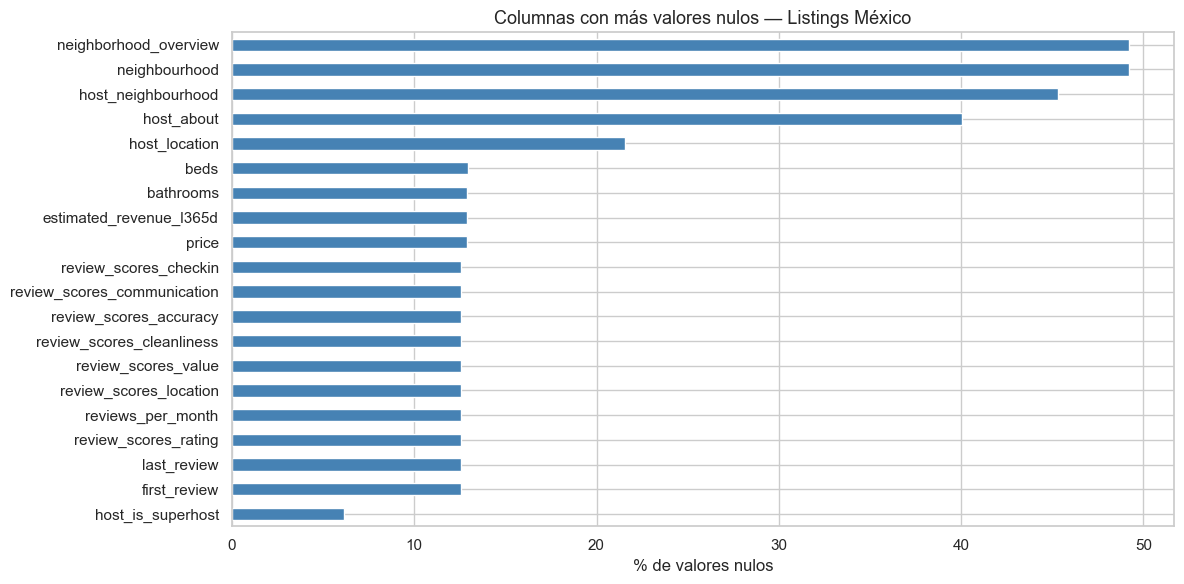

In [7]:
# Visualización de nulos en Listings
if not nulos_l.empty:
    top = nulos_l.head(20)
    fig, ax = plt.subplots(figsize=(12, 6))
    top['% Nulos'].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Columnas con más valores nulos — Listings México', fontsize=13)
    ax.set_xlabel('% de valores nulos')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

In [8]:
# Duplicados (excluye columnas no hashables como listas)
def contar_dup(df, nombre):
    cols = [c for c in df.columns
            if not df[c].apply(lambda x: isinstance(x, (list, dict))).any()]
    dup = df[cols].duplicated().sum()
    print(f'{nombre}: {dup:,} duplicados ({dup/len(df)*100:.2f}%)')

for n, d in [('Listings', df_listings), ('Reviews', df_reviews), ('Calendar', df_calendar)]:
    contar_dup(d, n)

Listings: 0 duplicados (0.00%)
Reviews: 0 duplicados (0.00%)
Calendar: 0 duplicados (0.00%)


---
## 4. Análisis de precios — Variable central del Taller 3

Este análisis no fue posible en Buenos Aires por ausencia del campo `price` en listings. En Ciudad de México sí está disponible y es la variable más relevante para el dashboard.

In [9]:
# Normalizar price si aún no está como numérico
if 'price' in df_listings.columns:
    df_listings['price_num'] = (
        df_listings['price']
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.strip()
    )
    df_listings['price_num'] = pd.to_numeric(df_listings['price_num'], errors='coerce')
    price = df_listings['price_num'].dropna()
    print('Estadísticas de precio (MXN por noche):')
    print(price.describe())
    print(f'\nTotal de listings con precio válido: {len(price):,} ({len(price)/len(df_listings)*100:.1f}%)')
    print(f'Listings sin precio: {df_listings["price_num"].isna().sum():,}')

Estadísticas de precio (MXN por noche):
count    23567.00
mean      1792.54
std      13230.94
min         61.00
25%        643.00
50%       1039.00
75%       1611.00
max     900000.00
Name: price_num, dtype: float64

Total de listings con precio válido: 23,567 (87.1%)
Listings sin precio: 3,484


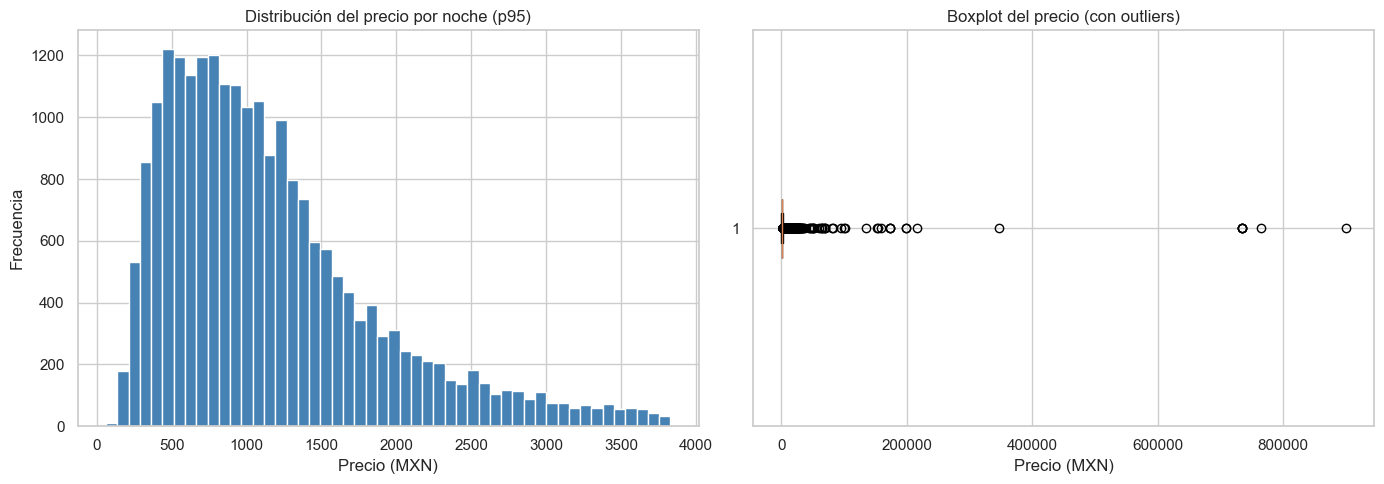

Mediana: $1,039 | Media: $1,793 | Máximo: $900,000
Interpretación: El precio tiene sesgo a la derecha con outliers muy altos. La mediana es más representativa que la media.


In [10]:
# Distribución del precio (filtrando outliers extremos)
p95 = price.quantile(0.95)
price_filtrado = price[price <= p95]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(price_filtrado, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución del precio por noche (p95)', fontsize=12)
axes[0].set_xlabel('Precio (MXN)')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(price, vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Boxplot del precio (con outliers)', fontsize=12)
axes[1].set_xlabel('Precio (MXN)')

plt.tight_layout()
plt.show()
print(f'Mediana: ${price.median():,.0f} | Media: ${price.mean():,.0f} | Máximo: ${price.max():,.0f}')
print('Interpretación: El precio tiene sesgo a la derecha con outliers muy altos.'
      ' La mediana es más representativa que la media.')

In [11]:
# Categorías de precio (creadas por el ETL)
if 'price_categoria' in df_listings.columns:
    orden = ['Economico', 'Moderado', 'Alto', 'Premium', 'Sin datos']
    conteo_cat = df_listings['price_categoria'].value_counts().reindex(orden).dropna()
    fig, ax = plt.subplots(figsize=(8, 5))
    conteo_cat.plot(kind='bar', ax=ax,
                    color=['#2ecc71','#3498db','#e67e22','#e74c3c','#95a5a6'],
                    edgecolor='white')
    ax.set_title('Distribución de alojamientos por categoría de precio', fontsize=12)
    ax.set_xlabel('Categoría')
    ax.set_ylabel('Cantidad de listings')
    ax.tick_params(axis='x', rotation=0)
    for i, v in enumerate(conteo_cat):
        ax.text(i, v + 10, f'{v:,}', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()
    print('Categorías: Económico ≤$50 | Moderado $51–$150 | Alto $151–$300 | Premium >$300')
    print('Interpretación: La distribución por categoría muestra el perfil de mercado'
          ' de Airbnb en CDMX.')

---
## 5. Precio por tipo de habitación

Precio por tipo de habitación:
                 Mediana    Media  Cantidad
room_type                                  
Hotel room       2000.00 42841.00        57
Entire home/apt  1250.00  1930.28     15896
Private room      580.00  1226.56      7360
Shared room       261.00   360.89       254


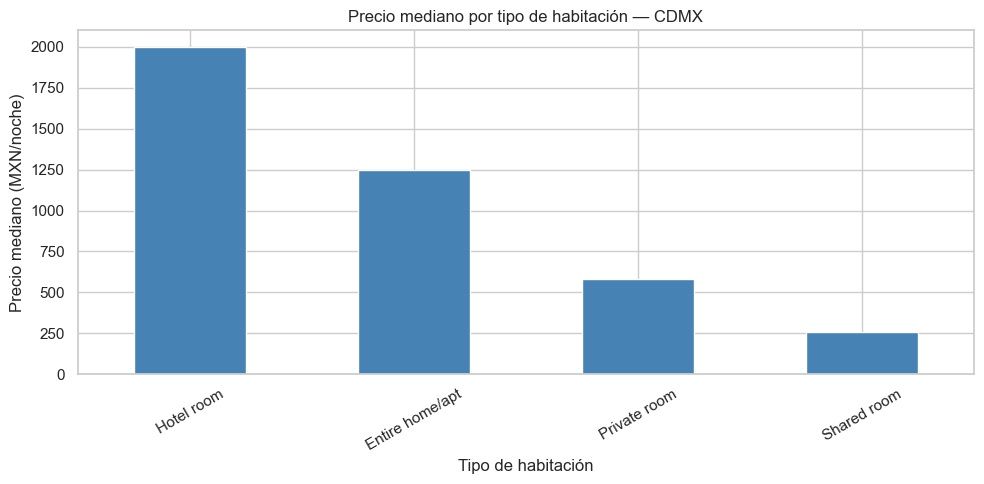

Interpretación: Los alojamientos completos tienen precios significativamente mayores que habitaciones privadas o compartidas.


In [12]:
if 'room_type' in df_listings.columns and 'price_num' in df_listings.columns:
    precio_room = (df_listings.groupby('room_type')['price_num']
                   .agg(['median', 'mean', 'count'])
                   .sort_values('median', ascending=False))
    precio_room.columns = ['Mediana', 'Media', 'Cantidad']
    print('Precio por tipo de habitación:')
    print(precio_room.to_string())

    fig, ax = plt.subplots(figsize=(10, 5))
    precio_room['Mediana'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Precio mediano por tipo de habitación — CDMX', fontsize=12)
    ax.set_xlabel('Tipo de habitación')
    ax.set_ylabel('Precio mediano (MXN/noche)')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()
    print('Interpretación: Los alojamientos completos tienen precios significativamente'
          ' mayores que habitaciones privadas o compartidas.')

---
## 6. Precio y oferta por barrio (Top 15)

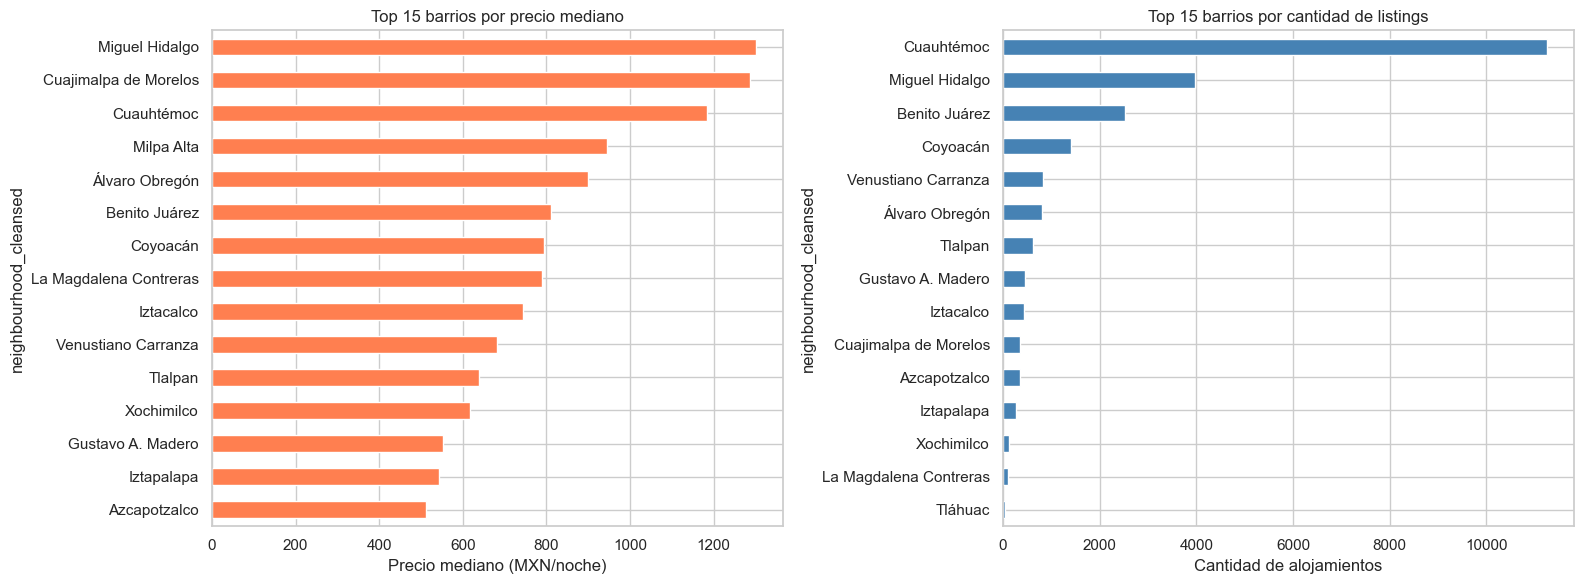

Interpretación: Los barrios con mayor precio no siempre son los de mayor oferta. Esto revela nichos premium en CDMX.


In [13]:
if 'neighbourhood_cleansed' in df_listings.columns and 'price_num' in df_listings.columns:
    precio_barrio = (df_listings.groupby('neighbourhood_cleansed')['price_num']
                     .agg(['median', 'count'])
                     .sort_values('median', ascending=False))
    precio_barrio.columns = ['Precio_mediano', 'Cantidad']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Top 15 por precio más alto
    top_precio = precio_barrio.head(15)
    top_precio['Precio_mediano'].plot(kind='barh', ax=axes[0], color='coral')
    axes[0].set_title('Top 15 barrios por precio mediano', fontsize=12)
    axes[0].set_xlabel('Precio mediano (MXN/noche)')
    axes[0].invert_yaxis()

    # Top 15 por cantidad de listings
    top_cantidad = precio_barrio.sort_values('Cantidad', ascending=False).head(15)
    top_cantidad['Cantidad'].plot(kind='barh', ax=axes[1], color='steelblue')
    axes[1].set_title('Top 15 barrios por cantidad de listings', fontsize=12)
    axes[1].set_xlabel('Cantidad de alojamientos')
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()
    print('Interpretación: Los barrios con mayor precio no siempre son los de mayor'
          ' oferta. Esto revela nichos premium en CDMX.')

---
## 7. Relación entre precio y disponibilidad

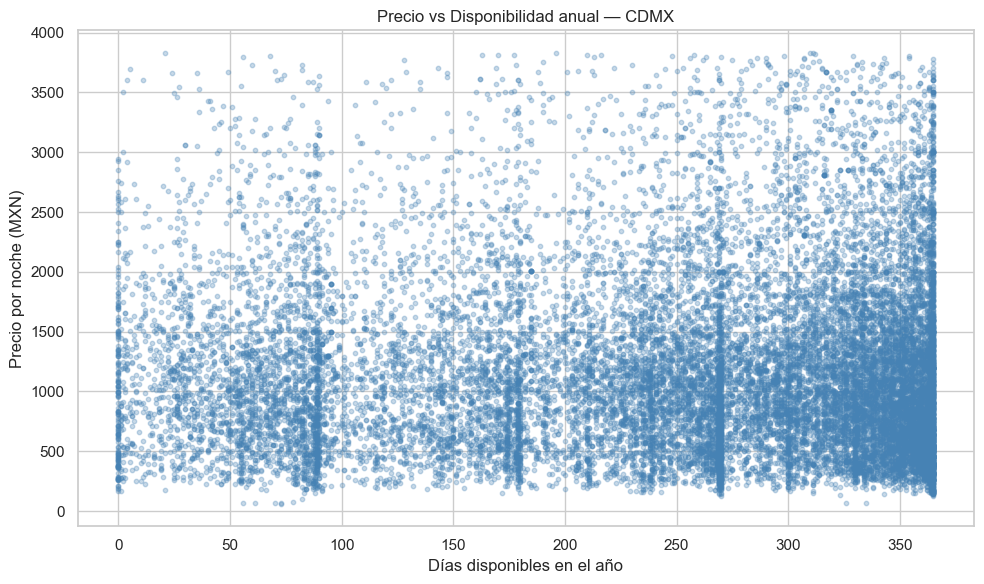

Correlación precio-disponibilidad: -0.022
Interpretación: Una correlación cercana a 0 indica que el precio no explica directamente la disponibilidad anual.


In [14]:
if 'availability_365' in df_listings.columns and 'price_num' in df_listings.columns:
    # Filtrar outliers para scatter legible
    df_scatter = df_listings[['price_num', 'availability_365']].dropna()
    df_scatter = df_scatter[df_scatter['price_num'] <= df_scatter['price_num'].quantile(0.95)]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(df_scatter['availability_365'], df_scatter['price_num'],
               alpha=0.3, color='steelblue', s=10)
    ax.set_title('Precio vs Disponibilidad anual — CDMX', fontsize=12)
    ax.set_xlabel('Días disponibles en el año')
    ax.set_ylabel('Precio por noche (MXN)')
    plt.tight_layout()
    plt.show()

    corr = df_scatter.corr()['price_num']['availability_365']
    print(f'Correlación precio-disponibilidad: {corr:.3f}')
    print('Interpretación: Una correlación cercana a 0 indica que el precio no'
          ' explica directamente la disponibilidad anual.')

---
## 8. Precio según superhost

              Precio_mediano  Cantidad
No Superhost          962.00     12775
Superhost            1125.00      9277


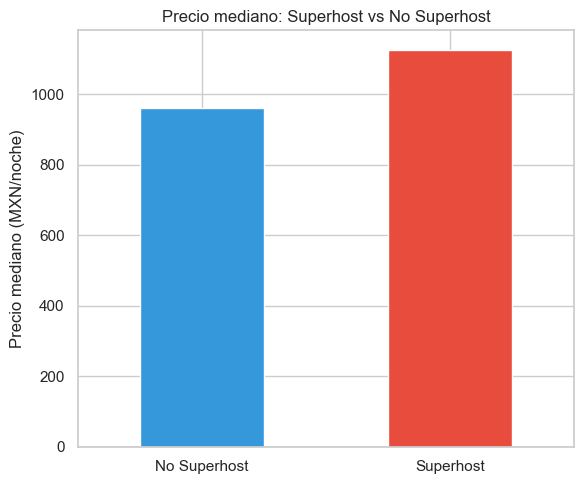

Interpretación: Comparar si los Superhosts cobran más o tienen precios similares al resto del mercado.


In [15]:
if 'host_is_superhost' in df_listings.columns and 'price_num' in df_listings.columns:
    grupos = df_listings.groupby('host_is_superhost')['price_num'].agg(['median', 'count'])
    grupos.index = ['No Superhost', 'Superhost']
    grupos.columns = ['Precio_mediano', 'Cantidad']
    print(grupos)

    fig, ax = plt.subplots(figsize=(6, 5))
    grupos['Precio_mediano'].plot(kind='bar', ax=ax,
                                  color=['#3498db', '#e74c3c'],
                                  edgecolor='white')
    ax.set_title('Precio mediano: Superhost vs No Superhost', fontsize=12)
    ax.set_ylabel('Precio mediano (MXN/noche)')
    ax.tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.show()
    print('Interpretación: Comparar si los Superhosts cobran más o tienen'
          ' precios similares al resto del mercado.')

---
## 9. Distribución por tipo de habitación

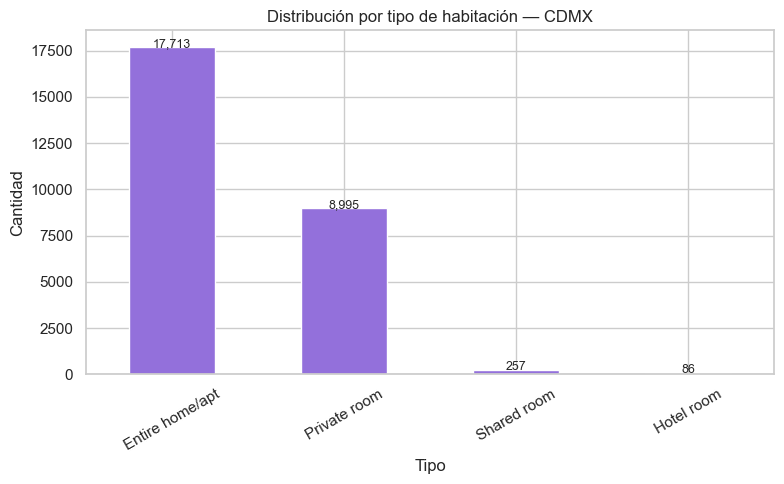

room_type
Entire home/apt    17713
Private room        8995
Shared room          257
Hotel room            86


In [16]:
if 'room_type' in df_listings.columns:
    conteo = df_listings['room_type'].value_counts()
    fig, ax = plt.subplots(figsize=(8, 5))
    conteo.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white')
    ax.set_title('Distribución por tipo de habitación — CDMX', fontsize=12)
    ax.set_xlabel('Tipo')
    ax.set_ylabel('Cantidad')
    ax.tick_params(axis='x', rotation=30)
    for i, v in enumerate(conteo):
        ax.text(i, v + 5, f'{v:,}', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()
    print(conteo.to_string())

---
## 10. Reviews — Evolución temporal

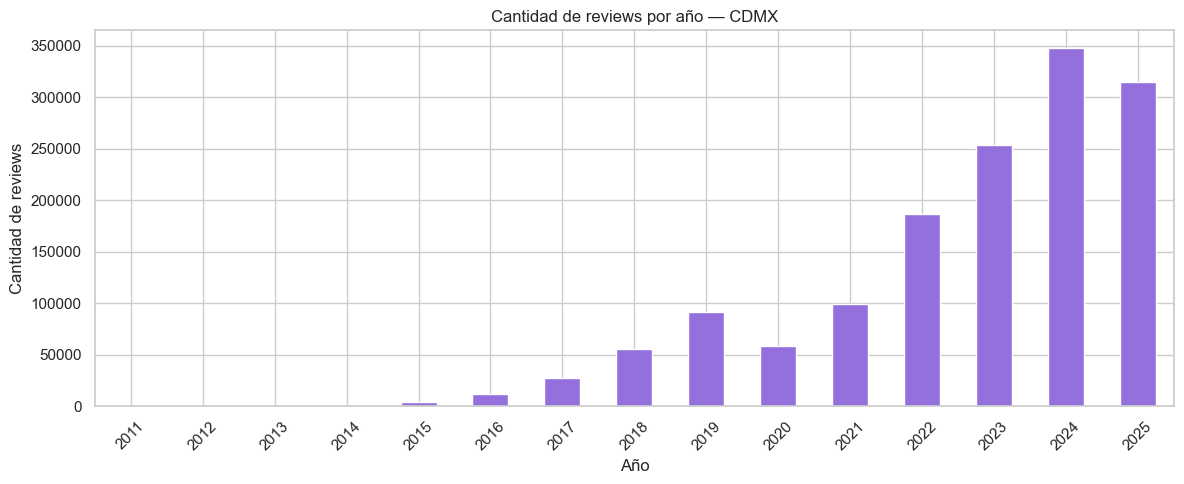

Interpretación: La evolución anual de reviews refleja el crecimiento de Airbnb en CDMX y el impacto de eventos como la pandemia.


In [17]:
if 'date' in df_reviews.columns:
    df_reviews['date_dt'] = pd.to_datetime(df_reviews['date'], errors='coerce')
    df_reviews['anio'] = df_reviews['date_dt'].dt.year
    conteo_anio = df_reviews['anio'].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(12, 5))
    conteo_anio.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white')
    ax.set_title('Cantidad de reviews por año — CDMX', fontsize=12)
    ax.set_xlabel('Año')
    ax.set_ylabel('Cantidad de reviews')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
    print('Interpretación: La evolución anual de reviews refleja el crecimiento'
          ' de Airbnb en CDMX y el impacto de eventos como la pandemia.')

---
## 11. Calendar — Disponibilidad por mes

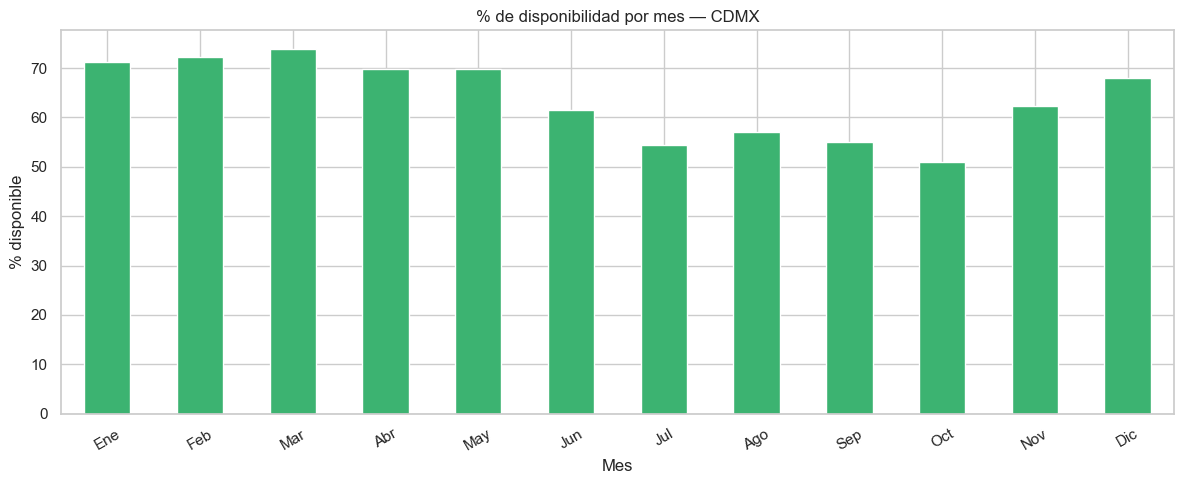

Interpretación: La estacionalidad de disponibilidad revela meses de alta y baja demanda turística en CDMX.


In [18]:
if 'date' in df_calendar.columns and 'available' in df_calendar.columns:
    df_cal = df_calendar.copy()
    df_cal['date_dt'] = pd.to_datetime(df_cal['date'], errors='coerce')
    df_cal['mes'] = df_cal['date_dt'].dt.month
    # available puede ser bool nativo o string 't'/'f'
    if df_cal['available'].dtype == bool:
        df_cal['disp'] = df_cal['available'].astype(int)
    else:
        df_cal['disp'] = df_cal['available'].map({'t': 1, 'f': 0, True: 1, False: 0})

    disp_mes = df_cal.groupby('mes')['disp'].mean() * 100

    fig, ax = plt.subplots(figsize=(12, 5))
    disp_mes.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white')
    ax.set_title('% de disponibilidad por mes — CDMX', fontsize=12)
    ax.set_xlabel('Mes')
    ax.set_ylabel('% disponible')
    ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                        'Jul','Ago','Sep','Oct','Nov','Dic'], rotation=30)
    plt.tight_layout()
    plt.show()
    print('Interpretación: La estacionalidad de disponibilidad revela meses de'
          ' alta y baja demanda turística en CDMX.')

---
## 12. Distribución de review scores

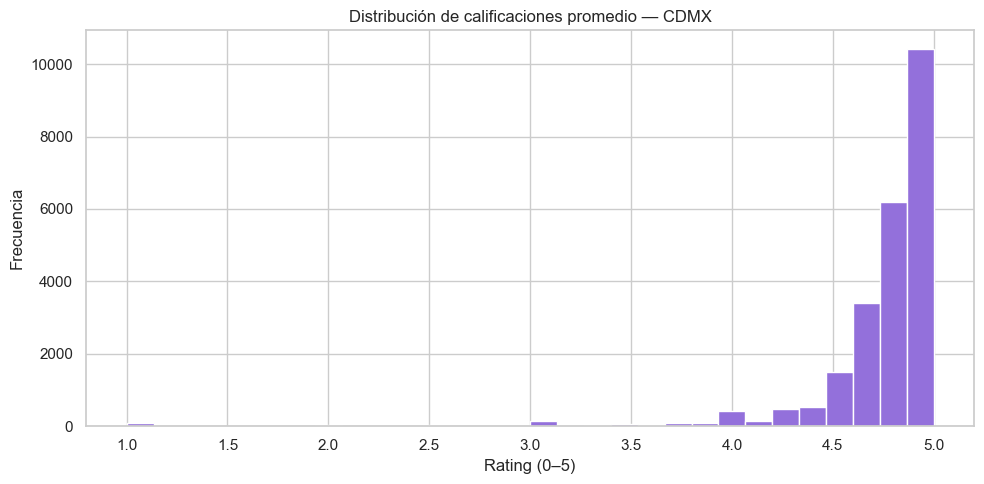

Media: 4.75 | Mediana: 4.84
Listings con calificación: 23,650 (87.4%)
Interpretación: La mayoría de los alojamientos tiene calificaciones altas, lo que es típico en plataformas de economía colaborativa.


In [19]:
if 'review_scores_rating' in df_listings.columns:
    rating = pd.to_numeric(df_listings['review_scores_rating'], errors='coerce').dropna()
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(rating, bins=30, color='mediumpurple', edgecolor='white')
    ax.set_title('Distribución de calificaciones promedio — CDMX', fontsize=12)
    ax.set_xlabel('Rating (0–5)')
    ax.set_ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()
    print(f'Media: {rating.mean():.2f} | Mediana: {rating.median():.2f}')
    print(f'Listings con calificación: {len(rating):,} ({len(rating)/len(df_listings)*100:.1f}%)')
    print('Interpretación: La mayoría de los alojamientos tiene calificaciones'
          ' altas, lo que es típico en plataformas de economía colaborativa.')

---
## 13. Relación precio vs calificación

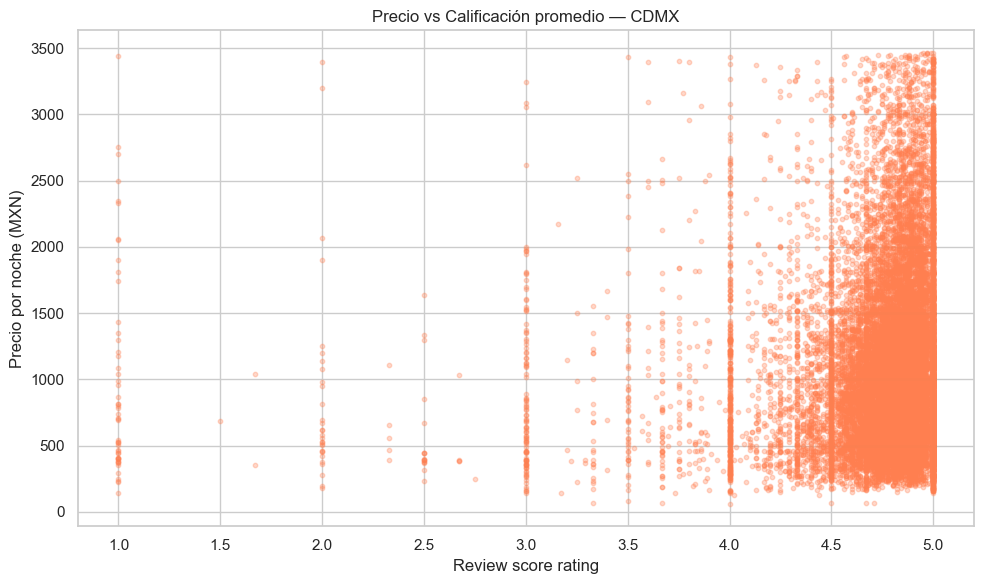

Correlación precio–calificación: 0.095
Interpretación: Una correlación baja indica que un precio más alto no garantiza una mejor calificación.


In [20]:
if 'review_scores_rating' in df_listings.columns and 'price_num' in df_listings.columns:
    df_pr = df_listings[['price_num', 'review_scores_rating']].dropna()
    df_pr = df_pr[df_pr['price_num'] <= df_pr['price_num'].quantile(0.95)]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(df_pr['review_scores_rating'], df_pr['price_num'],
               alpha=0.3, color='coral', s=10)
    ax.set_title('Precio vs Calificación promedio — CDMX', fontsize=12)
    ax.set_xlabel('Review score rating')
    ax.set_ylabel('Precio por noche (MXN)')
    plt.tight_layout()
    plt.show()

    corr = df_pr.corr()['price_num']['review_scores_rating']
    print(f'Correlación precio–calificación: {corr:.3f}')
    print('Interpretación: Una correlación baja indica que un precio más alto'
          ' no garantiza una mejor calificación.')

---
## 14. Amenities — Cantidad por alojamiento

In [21]:
if 'amenities_cantidad' in df_listings.columns:
    am = pd.to_numeric(df_listings['amenities_cantidad'], errors='coerce').dropna()
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(am, bins=30, color='steelblue', edgecolor='white')
    ax.set_title('Distribución de cantidad de amenities por listing', fontsize=12)
    ax.set_xlabel('Número de amenities')
    ax.set_ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()
    print(f'Media: {am.mean():.1f} amenities | Máximo: {am.max():.0f}')

---
## 15. Resumen de hallazgos — Insumo para el informe del Taller 3

### Listings
- El dataset de CDMX **sí contiene `price`** directamente, a diferencia de Buenos Aires.
- El precio tiene distribución sesgada a la derecha: la mediana es más representativa que la media.
- La mayoría de listings cae en la categoría **Moderado** ($51–$150 USD/noche).
- Whole home/apt es el tipo de alojamiento más frecuente y con precio más alto.
- Existen diferencias de precio significativas entre barrios, revelando zonas premium.
- Los Superhosts no necesariamente cobran más que los anfitriones regulares.

### Reviews
- La evolución temporal de reviews muestra el crecimiento histórico y el impacto de la pandemia.
- La mayoría de alojamientos con reseñas tienen calificaciones altas (4.5+).
- No hay correlación fuerte entre precio y calificación.

### Calendar
- La disponibilidad varía por mes, reflejando estacionalidad turística en CDMX.
- Los meses de menor disponibilidad corresponden a temporadas de mayor demanda.

### Variables clave para el Dashboard de Power BI
| Variable | Tabla | Uso en dashboard |
|---|---|---|
| `price` | listings | KPI principal, histograma, comparación |
| `price_categoria` | listings | Segmentación, filtro |
| `neighbourhood_cleansed` | listings | Comparación geográfica |
| `room_type` | listings | Segmentación por tipo |
| `host_is_superhost` | listings | Comparación de perfiles |
| `availability_365` | listings | Ocupación estimada |
| `review_scores_rating` | listings | Calidad percibida |
| `date` | reviews | Tendencia temporal |
| `available` | calendar | Disponibilidad mensual |